# Food-101 Image Classification

## 1 Introduction

## 2 Project Setup

### 2.1 Package setup

In [1]:
try:
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    !pip install torch torchvision
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.0.1
torchvision version: 0.15.2


In [2]:
from torch import nn
from torchvision import transforms
from torchinfo import summary

In [3]:
# Set up device agnostic code
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Your device is using {device} to train the models")

Your device is using mps to train the models


Setting a random seed is a crucial practice for ensuring reproducibility and consistent results. It provides a solid foundation for analysis, experimentation, and model development by reducing the impact of randomness on your results.

In [4]:
# Set seeds
def set_seeds(seed: int=0):
    # Set seed for CUDA torch operations
    torch.cuda.manual_seed(seed)
    
    # Set seed for MPS torch operations
    torch.mps.manual_seed(seed)
    
    # Set seed for general torch operations
    torch.manual_seed(seed)

### 2.1 Download Dataset

In [5]:
import requests
import zipfile
from pathlib import Path

In [6]:
# Setup path to data folder
data_path = Path("dataset/")
image_path = data_path / "images"

# If the dataset doesn't exist, download and prepare it 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
#     image_path.mkdir(parents=True, exist_ok=True)
    
#     # Download pizza, steak, sushi data
#     with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
#         request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
#         print("Downloading pizza, steak, sushi data...")
#         f.write(request.content)

#     # Unzip pizza, steak, sushi data
#     with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
#         print("Unzipping pizza, steak, sushi data...") 
#         zip_ref.extractall(image_path)

dataset/images directory exists.


## 3 Data Preprocessing

### 3.1 Moving Training and Testing Images to Dedicated Folders

In [7]:
import os
import random
import shutil

In [8]:
def create_train_test_split(data_directory, train_ratio, subset_percentage):
    # Create directories for training and testing data
    train_dir = os.path.join(data_directory, "train")
    test_dir = os.path.join(data_directory, "test")
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    # Iterate through each class folder
    for class_folder in os.listdir(data_directory):
        class_path = os.path.join(data_directory, class_folder)

        # Check if the item in the directory is a subdirectory (class folder)
        if os.path.isdir(class_path):
            # Get a list of image files in the class folder
            class_images = [img for img in os.listdir(class_path) if img.endswith(".jpg")]
            
            # Shuffle the list of images
            random.shuffle(class_images)
            
            # Calculate the number of selected images based on the subset percentage
            num_images = len(class_images)
            num_selected = int(num_images * subset_percentage)
            selected_images = class_images[:num_selected]

            # Calculate the number of images for training and testing
            num_train = int(num_selected * train_ratio)
            train_images = selected_images[:num_train]
            test_images = selected_images[num_train:]

            # Copy selected training images to the training directory
            for img in train_images:
                src_path = os.path.join(class_path, img)
                dst_path = os.path.join(train_dir, class_folder, img)
                os.makedirs(os.path.dirname(dst_path), exist_ok=True)
                shutil.copy(src_path, dst_path)

            # Copy selected testing images to the testing directory
            for img in test_images:
                src_path = os.path.join(class_path, img)
                dst_path = os.path.join(test_dir, class_folder, img)
                os.makedirs(os.path.dirname(dst_path), exist_ok=True)
                shutil.copy(src_path, dst_path)

In [9]:
# Path to data directory
data_directory = image_path

# Split the dataset into 80% for training, 20% for testing
train_ratio = 0.8 

# Take 10% of images from each class
subset_percentage = 0.5

create_train_test_split(data_directory, train_ratio, subset_percentage)

### 3.2 Load Dataset

In [10]:
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory
  
  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [11]:
walk_through_dir(image_path)

There are 7 directories and 1 images in 'dataset/images'.
There are 0 directories and 1000 images in 'dataset/images/french_toast'.
There are 5 directories and 0 images in 'dataset/images/test'.
There are 0 directories and 100 images in 'dataset/images/test/french_toast'.
There are 0 directories and 100 images in 'dataset/images/test/red_velvet_cake'.
There are 0 directories and 100 images in 'dataset/images/test/grilled_cheese_sandwich'.
There are 0 directories and 100 images in 'dataset/images/test/apple_pie'.
There are 0 directories and 100 images in 'dataset/images/test/pancakes'.
There are 0 directories and 1000 images in 'dataset/images/red_velvet_cake'.
There are 0 directories and 1000 images in 'dataset/images/grilled_cheese_sandwich'.
There are 0 directories and 1000 images in 'dataset/images/apple_pie'.
There are 5 directories and 0 images in 'dataset/images/train'.
There are 0 directories and 400 images in 'dataset/images/train/french_toast'.
There are 0 directories and 400 

In [12]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('dataset/images/train'), PosixPath('dataset/images/test'))

### 3.3 Data Exploration

Taking a look at the properties of an image

In [13]:
from PIL import Image
import random

Image Properties:
Filename: dataset/images/train/apple_pie/649621.jpg
Format: JPEG
Size: (512, 512)
Mode: RGB


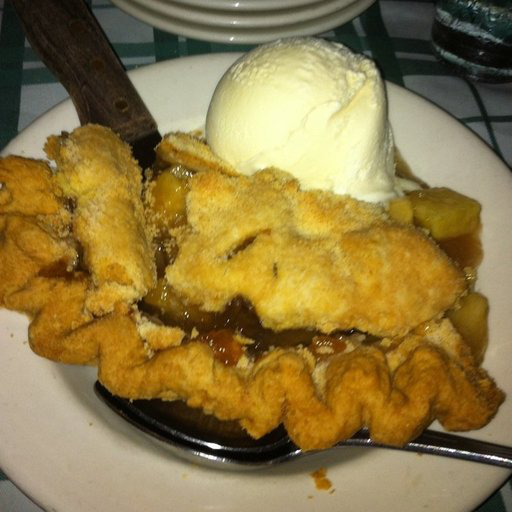

In [14]:
# Get the path to all the images in the directory
image_path_list = list(image_path.glob("*/*/*.jpg"))

# Choose a random image filename from the list
random_image_filename = random.choice(image_path_list)

# Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_filename.parent.stem

# Open image
image = Image.open(random_image_filename)

# Print image properties
print("Image Properties:")
print(f"Filename: {random_image_filename}")
print(f"Format: {image.format}")
print(f"Size: {image.size}")
print(f"Mode: {image.mode}")  # 'RGB' for color images, 'L' for grayscale

# Display the image
image

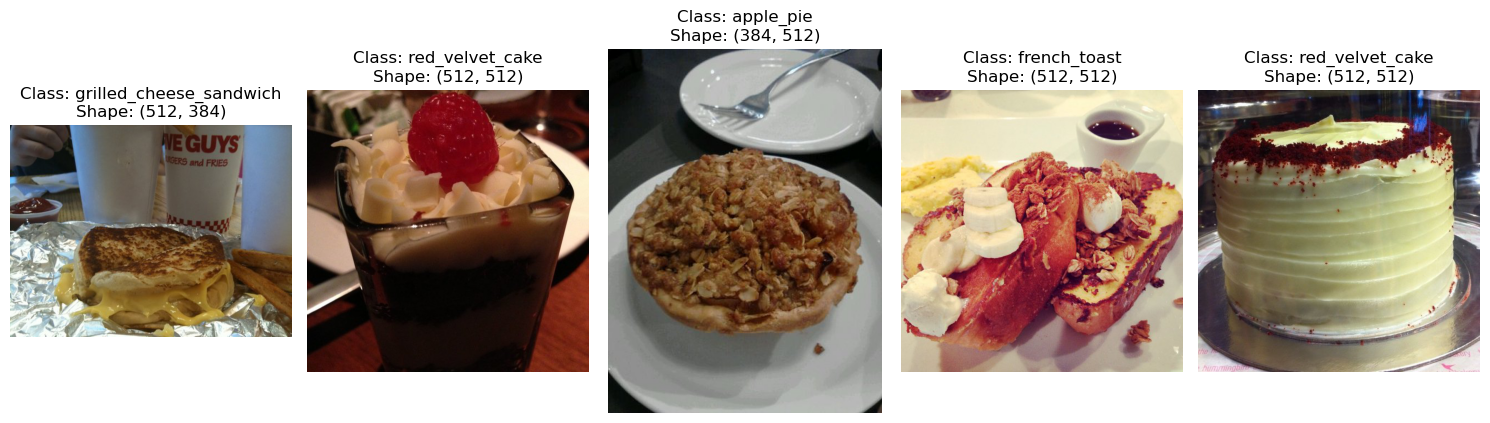

In [15]:
import matplotlib.pyplot as plt

# Get a list of class folders (class names)
class_folders = os.listdir(train_dir)

# Initialize a Matplotlib figure to display the images
plt.figure(figsize=(15, 8))

# Display 5 random images
for _ in range(5):
    # Choose a random class folder
    random_class_folder = random.choice(class_folders)
    
    # Get a list of image filenames in the class folder
    class_path = os.path.join(train_dir, random_class_folder)
    image_filenames = [filename for filename in os.listdir(class_path) if filename.endswith(".jpg")]
    
    # Choose a random image filename from the class folder
    random_image_filename = random.choice(image_filenames)
    
    # Load the random image using Pillow
    random_image_path = os.path.join(class_path, random_image_filename)
    image = Image.open(random_image_path)
    
    # Get class name from class folder
    class_name = random_class_folder
    
    # Display the image with class name and shape
    plt.subplot(2, 5, _ + 1)
    plt.imshow(image)
    plt.title(f"Class: {class_name}\nShape: {image.size}")
    plt.axis("off")

# Show the plot with all 5 random images
plt.tight_layout()
plt.show()

In [16]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir, # target folder of images
                                  target_transform=None) # transforms to perform on labels (if necessary)

test_data = datasets.ImageFolder(root=test_dir)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 2000
    Root location: dataset/images/train
Test data:
Dataset ImageFolder
    Number of datapoints: 500
    Root location: dataset/images/test


### 3.4 Data Transformation

In [17]:
# Import data_setup.py
from helper_functions import data_setup

# Create a simple transformation
simple_transform = transforms.Compose([ 
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Create train/test dataloader and get class names as a list
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=simple_transform,
    batch_size=32
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x15380b460>,
 ['apple_pie',
  'french_toast',
  'grilled_cheese_sandwich',
  'pancakes',
  'red_velvet_cake'])

In [18]:
img, label = next(iter(train_dataloader))

print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


## 4 Building the Image Classification Model

### 4.1 Building a Simple TinyVGG Model 

In [19]:
from helper_functions import models

# Create an instance of the SimpleVGG model
simple_vgg_model = models.SimpleVGG(input_shape=3,
                         hidden_units=10,
                         output_shape=len(class_names)).to("cpu")

# Print the model architecture
print(simple_vgg_model)

SimpleVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=5, bias=True)
  )
)


### 4.2 Testing the Model with a Single Pass

Predicted class: french_toast
Probabilities:
apple_pie: 0.2006
french_toast: 0.2042
grilled_cheese_sandwich: 0.2005
pancakes: 0.1975
red_velvet_cake: 0.1973


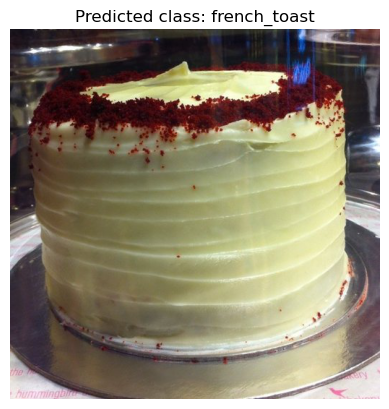

In [20]:
# 1. Get a batch of images and labels from the DataLoader
img_batch, label_batch = next(iter(train_dataloader))

# 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]

# Set the model to evaluation mode
simple_vgg_model.eval()

# Perform inference
with torch.no_grad():
    output = simple_vgg_model(img_single)

# Convert the output to probabilities using softmax
probs = torch.softmax(output[0], dim=0)

# Get the predicted class index
predicted_class_idx = torch.argmax(probs).item()

# Get the predicted class label
predicted_class_label = class_names[predicted_class_idx]

# Print the predicted class label and probabilities
print(f'Predicted class: {predicted_class_label}')
print('Probabilities:')
for i, prob in enumerate(probs):
    print(f'{class_names[i]}: {prob:.4f}')

# Display the input image
plt.imshow(image)
plt.axis('off')
plt.title(f'Predicted class: {predicted_class_label}')
plt.show()

In [21]:
# Examine how the image goes through the model
summary(model=simple_vgg_model, input_size=img_single.shape)

Layer (type:depth-idx)                   Output Shape              Param #
SimpleVGG                                [1, 5]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

### 4.3 Train Model

In [22]:
# Set number of epochs
NUM_EPOCHS = 10

# Set the loss function
loss_fn = nn.CrossEntropyLoss()

# Set the optimizer
optimizer = torch.optim.Adam(simple_vgg_model.parameters(), lr=0.001)

In [23]:
from helper_functions import engine

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Setup training and save the results
simple_vgg_model_results = engine.train_and_test_model(model=simple_vgg_model,
                                                       train_dataloader=train_dataloader,
                                                       test_dataloader=test_dataloader,
                                                       optimizer=optimizer,
                                                       loss_fn=loss_fn,
                                                       epochs=NUM_EPOCHS,
                                                       device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

Epoch [1/10]


/Users/winsonchow/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train Loss: 1.6089 - Train Accuracy: 0.2000
Test Loss: 1.5948 - Test Accuracy: 0.2080
Epoch [2/10]
Train Loss: 1.5522 - Train Accuracy: 0.2855
Test Loss: 1.4757 - Test Accuracy: 0.3160
Epoch [3/10]
Train Loss: 1.4491 - Train Accuracy: 0.3480
Test Loss: 1.3991 - Test Accuracy: 0.3520
Epoch [4/10]
Train Loss: 1.4039 - Train Accuracy: 0.3570
Test Loss: 1.3737 - Test Accuracy: 0.3840
Epoch [5/10]
Train Loss: 1.3672 - Train Accuracy: 0.3810
Test Loss: 1.3404 - Test Accuracy: 0.3940
Epoch [6/10]
Train Loss: 1.3474 - Train Accuracy: 0.4020
Test Loss: 1.3419 - Test Accuracy: 0.3980
Epoch [7/10]
Train Loss: 1.3326 - Train Accuracy: 0.4060
Test Loss: 1.3280 - Test Accuracy: 0.4000
Epoch [8/10]
Train Loss: 1.3242 - Train Accuracy: 0.4250
Test Loss: 1.3439 - Test Accuracy: 0.4020
Epoch [9/10]
Train Loss: 1.3197 - Train Accuracy: 0.4235
Test Loss: 1.3336 - Test Accuracy: 0.4140
Epoch [10/10]
Train Loss: 1.3037 - Train Accuracy: 0.4300
Test Loss: 1.3274 - Test Accuracy: 0.3920
[INFO] Total training 

In [24]:
simple_vgg_model_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

### 4.4 Evaluate Model

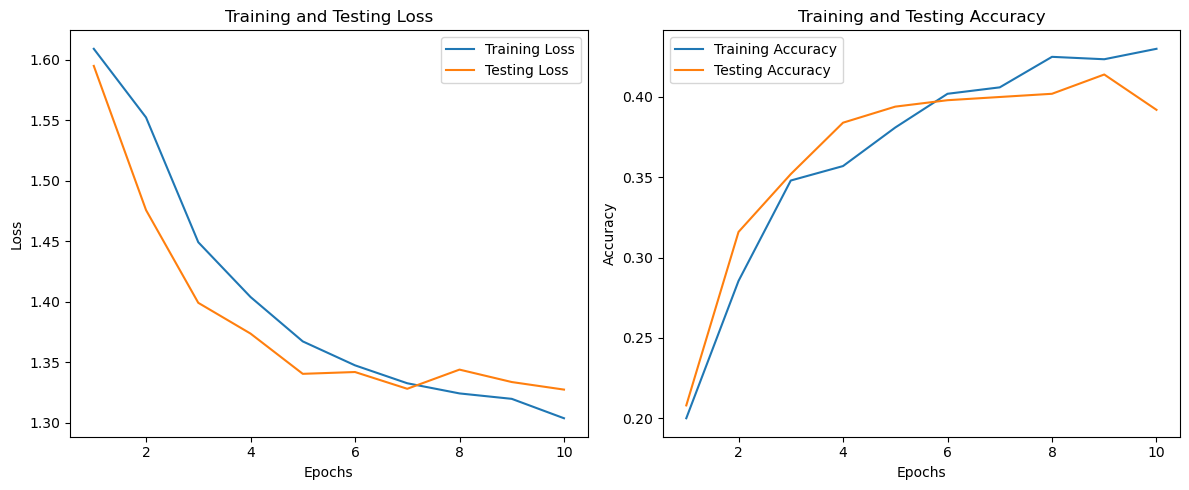

In [25]:
from helper_functions import plot_graphs

plot_graphs.plot_metrics(simple_vgg_model_results)

## 5 Transfer Learning: Leveraging a Pretrained Model

### 5.1 Setting Up a Pretrained Model

In [26]:
from torchvision.models import resnet50, ResNet50_Weights

In [27]:
# Initialize the Weight Transforms
weights = ResNet50_Weights.DEFAULT

# Get the transforms used to create our pretrained weights
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [28]:
# Setup the ResNet50 model with pretrained weights and send it to the target device
resnet50_model = resnet50(weights=weights).to(device)
resnet50_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [29]:
# Print a summary of the ResNet50 model
summary(model=resnet50_model, input_size=(32,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 1000]                --
├─Conv2d: 1-1                            [32, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        128
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 256, 56, 56]         --
│    └─Bottleneck: 2-1                   [32, 256, 56, 56]         --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          4,096
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]          --
│ 

### 5.2 Modifying the Output Layer to our Needs

In [30]:
# Retrieve the number of classes
num_classes = len(class_names)

# Recreate the classifier layer and move it to the target device
resnet50_model.fc = nn.Linear(resnet50_model.fc.in_features, num_classes)

# Move the classifier layer to the target device
resnet50_model.fc.to(device)

# Freeze the base layers (pretrained layers)
for param in resnet50_model.parameters():
    param.requires_grad = False

# Enable gradient calculation for the classifier layer
for param in resnet50_model.fc.parameters():
    param.requires_grad = True
    
# Set up loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet50_model.fc.parameters(), lr=0.001)

# Print a summary of the ResNet50 model
summary(model=resnet50_model, input_size=(32,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 5]                   --
├─Conv2d: 1-1                            [32, 64, 112, 112]        (9,408)
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        (128)
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 256, 56, 56]         --
│    └─Bottleneck: 2-1                   [32, 256, 56, 56]         --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          (4,096)
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          (36,864)
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]   

### 5.3 Train Model

In [31]:
start_time = timer()

# Setup training and save the results
resnet50_model_results = engine.train_and_test_model(model=resnet50_model,
                                                       train_dataloader=train_dataloader,
                                                       test_dataloader=test_dataloader,
                                                       optimizer=optimizer,
                                                       loss_fn=loss_fn,
                                                       epochs=NUM_EPOCHS,
                                                       device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

Epoch [1/10]
Train Loss: 1.4051 - Train Accuracy: 0.4095
Test Loss: 1.2739 - Test Accuracy: 0.4800
Epoch [2/10]
Train Loss: 1.1149 - Train Accuracy: 0.5910
Test Loss: 1.1891 - Test Accuracy: 0.5140
Epoch [3/10]
Train Loss: 1.0006 - Train Accuracy: 0.6390
Test Loss: 1.1400 - Test Accuracy: 0.5400
Epoch [4/10]
Train Loss: 0.9314 - Train Accuracy: 0.6840
Test Loss: 1.1841 - Test Accuracy: 0.5300
Epoch [5/10]
Train Loss: 0.8653 - Train Accuracy: 0.6985
Test Loss: 1.1334 - Test Accuracy: 0.5540
Epoch [6/10]
Train Loss: 0.8210 - Train Accuracy: 0.7220
Test Loss: 1.1317 - Test Accuracy: 0.5500
Epoch [7/10]
Train Loss: 0.8022 - Train Accuracy: 0.7160
Test Loss: 1.1234 - Test Accuracy: 0.5400
Epoch [8/10]
Train Loss: 0.7503 - Train Accuracy: 0.7425
Test Loss: 1.1253 - Test Accuracy: 0.5580
Epoch [9/10]
Train Loss: 0.7311 - Train Accuracy: 0.7530
Test Loss: 1.1639 - Test Accuracy: 0.5420
Epoch [10/10]
Train Loss: 0.6950 - Train Accuracy: 0.7655
Test Loss: 1.2218 - Test Accuracy: 0.5420
[INFO] To

### 5.4 Evaluate Model

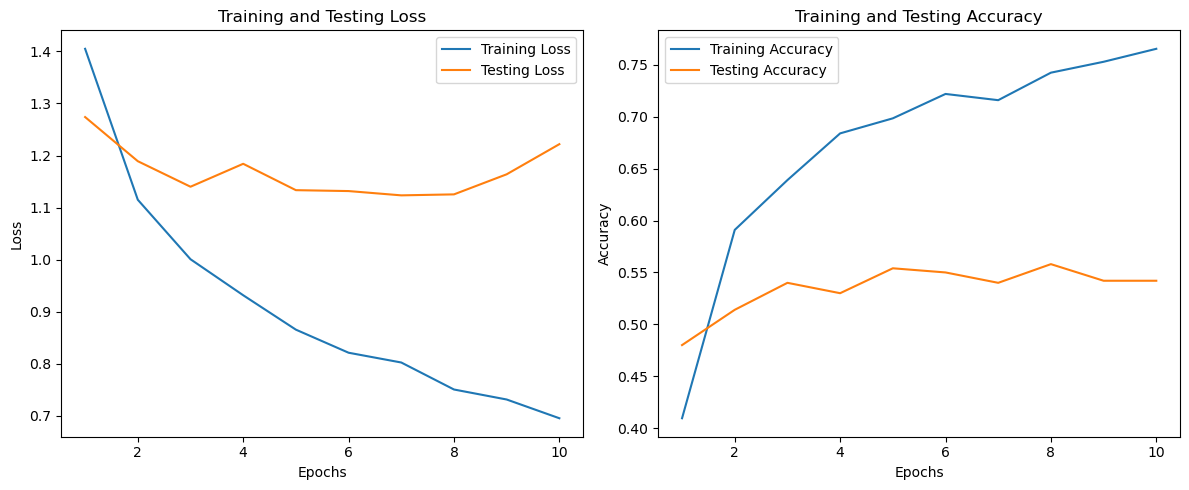

In [32]:
plot_graphs.plot_metrics(resnet50_model_results)

## 6 Setting Up a Series of Modelling Experiments

### 6.1 Modeling Fine-Tuning and Optimization

### 6.2 View experiments in TensorBoard

## 7 Loading the Best Model and Making Predictions

## 8 Conclusion